# ExSEnt: métrica de entropía para los registros neuronales intracelulares

#### Los códigos necesarios para ejecutar la entropía, tanto de la amplitud, como de duración y su correlación se encuentran en: 
https://github.com/GNB-UAM/Kamali_et_al_ExSEnt_Extrema-segmented_Entropy_Analysis_of_Time_Series

ExSEnt: Extrema-Segmented Entropy Analysis of Time Series
S. Kamali, F. Baroni, P. Varona
https://doi.org/10.48550/arXiv.2509.07751

### Los valores obtenidos son los siguientes, lo meto en formato diccionario para generar la gráfica de resultados.

In [2]:
import pandas as pd

datos_exsent = [
    (8,  500,  "control", 1.2779, 0.0269, 0.4597),
    (8,  500,  "laser",   1.3290, 0.0354, 0.4775),
    (8,  500,  "rec",     1.0294, 0.0197, 0.3955),
    (9,  700,  "control", 1.2801, 0.0189, 0.4593),
    (9,  700,  "laser",   1.1829, 0.0988, 0.5045),
    (9,  700,  "rec",     1.0632, 0.0304, 0.4137),
    (10, 900,  "control", 1.4318, 0.0292, 0.4991),
    (10, 900,  "laser",   1.3878, 0.0812, 0.5270),
    (10, 900,  "rec",     1.3095, 0.0328, 0.4760),
    (11, 1000, "control", 1.2929, 0.0324, 0.4722),
    (11, 1000, "laser",   1.2226, 0.1220, 0.5108),
    (11, 1000, "rec",     1.2138, 0.0355, 0.4558),
    (12, 1100, "control", 1.2051, 0.0396, 0.4575),
    (12, 1100, "laser",   1.2279, 0.3773, 0.6665),
    (12, 1100, "rec",     1.2139, 0.0440, 0.4599),
    (13, 1200, "control", 1.1825, 0.0504, 0.4549),
    (13, 1200, "laser",   1.3648, 0.7654, 0.9208),
    (13, 1200, "rec",     1.2148, 0.0456, 0.4650),
    (14, 1400, "control", 1.2547, 0.0459, 0.4731),
    (14, 1400, "laser",   1.1343, 0.9414, 0.8799),
    (14, 1400, "rec",     1.1856, 0.0509, 0.4587),
]

df_ent = pd.DataFrame(datos_exsent, columns=["archivo", "mA", "fase", "HD", "HA", "H_DA"])

colores_fase = {"control": "#1a6fad", "laser": "#c0392b", "rec": "#2e7d32"}
fases  = ["control", "laser", "rec"]
labels = ["Control", "Láser", "Recuperación"]
mAs  = [500, 700, 900, 1000, 1100, 1200, 1400]
df_ent

,archivo,mA,fase,HD,HA,H_DA
0,8,500,control,1.2779,0.0269,0.4597
1,8,500,laser,1.3290,0.0354,0.4775
2,8,500,rec,1.0294,0.0197,0.3955
3,9,700,control,1.2801,0.0189,0.4593
4,9,700,laser,1.1829,0.0988,0.5045
5,9,700,rec,1.0632,0.0304,0.4137
6,10,900,control,1.4318,0.0292,0.4991
7,10,900,laser,1.3878,0.0812,0.5270
8,10,900,rec,1.3095,0.0328,0.4760
9,11,1000,control,1.2929,0.0324,0.4722


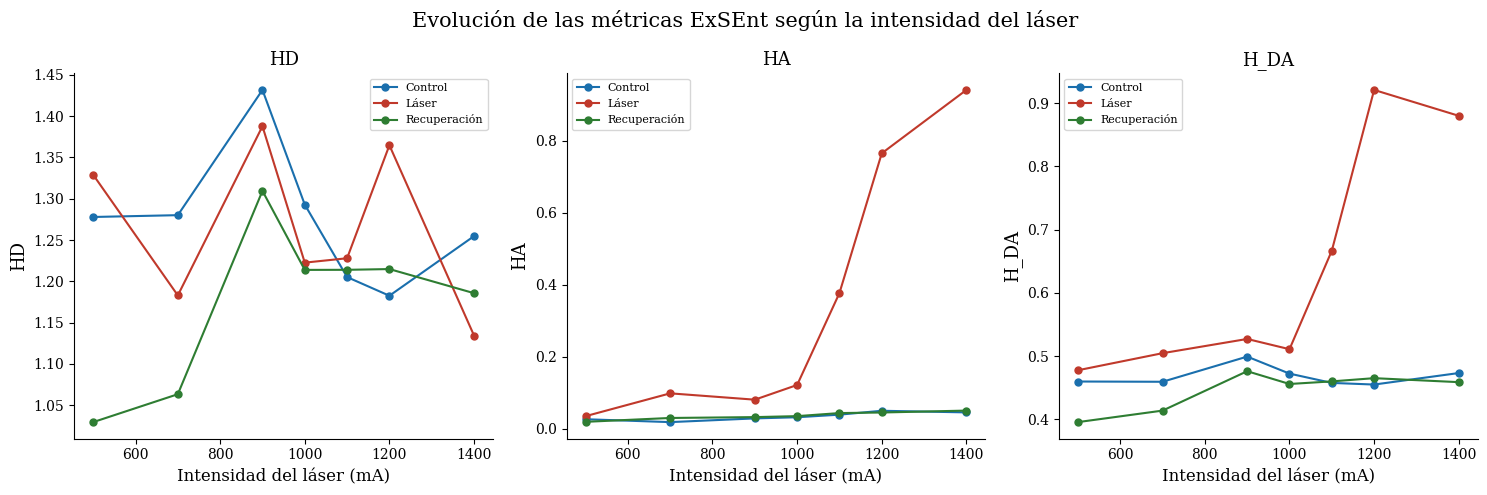

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Evolución de las métricas ExSEnt según la intensidad del láser", fontsize=15)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

metricas = [("HD", "HD"), ("HA", "HA"), ("H_DA", "H_DA")]

for ax, (col, titulo) in zip(axes, metricas):
    for fase, label in zip(fases, labels):
        valores = [df_ent[(df_ent.mA == ma) & (df_ent.fase == fase)][col].values[0] for ma in mAs]
        ax.plot(mAs, valores, marker='o', label=label,
                color=colores_fase[fase], linewidth=1.5, markersize=5)
    ax.set_xlabel("Intensidad del láser (mA)", fontsize=12)
    ax.set_ylabel(titulo, fontsize=13)
    ax.set_title(titulo, fontsize=13)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()